In [1]:
from rdkit import Chem

# Aspirin molecule
mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')

# Pattern dhoondhna — Benzene ring
benzene = Chem.MolFromSmiles('c1ccccc1')

# Check karo
has_benzene = mol.HasSubstructMatch(benzene)
print("Benzene ring present?", has_benzene)

# Carboxylic acid (-COOH) pattern
cooh = Chem.MolFromSmarts('C(=O)O')
has_cooh = mol.HasSubstructMatch(cooh)
print("COOH group present?", has_cooh)

Benzene ring present? True
COOH group present? True


In [2]:
from rdkit import Chem

# Tumhara compound
mol = Chem.MolFromSmiles('C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O')

# Different patterns check karo
patterns = {
    "Benzene ring":    'c1ccccc1',
    "Carbonyl (C=O)":  'C=O',
    "Selenium atom":   '[Se]',
    "C-Se-C linkage":  'C[Se]C',
    "COOH group":      'C(=O)O'
}

for name, smarts in patterns.items():
    pattern = Chem.MolFromSmarts(smarts)
    found = mol.HasSubstructMatch(pattern)
    status = "✅ Present" if found else "❌ Absent"
    print(f"{name:20} {status}")

Benzene ring         ✅ Present
Carbonyl (C=O)       ✅ Present
Selenium atom        ✅ Present
C-Se-C linkage       ✅ Present
COOH group           ❌ Absent


Matched atoms: (7, 8, 9)


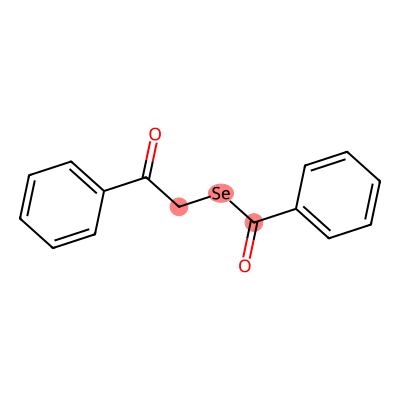

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw

# Tumhara compound
mol = Chem.MolFromSmiles('C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O')

# Selenium aur uske around ka pattern
pattern = Chem.MolFromSmarts('C[Se]C')

# Match dhoondho
match = mol.GetSubstructMatch(pattern)
print("Matched atoms:", match)

# Highlight karke draw karo
img = Draw.MolToImage(mol, size=(400, 400), highlightAtoms=match)
img

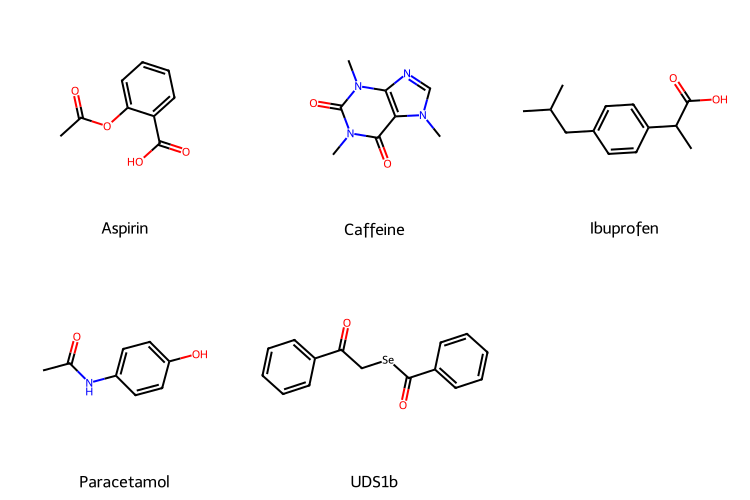

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

# Multiple molecules
smiles_list = [
    'CC(=O)Oc1ccccc1C(=O)O',                              # Aspirin
    'Cn1cnc2c1c(=O)n(C)c(=O)n2C',                         # Caffeine
    'CC(C)Cc1ccc(C(C)C(=O)O)cc1',                         # Ibuprofen
    'CC(=O)Nc1ccc(O)cc1',                                 # Paracetamol
    'C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O'              # UDS1b
]

names = ['Aspirin', 'Caffeine', 'Ibuprofen', 'Paracetamol', 'UDS1b']

# Sab molecules banao
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# Grid mein draw karo
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(250, 250),
    legends=names
)
img

In [5]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

# Tumhara compound
mol = Chem.MolFromSmiles('C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O')

# Hydrogen atoms add karo (3D ke liye zaroori)
mol = Chem.AddHs(mol)

# 3D coordinates generate karo
AllChem.EmbedMolecule(mol, randomSeed=42)

# Energy minimize karo (real shape paane ke liye)
AllChem.MMFFOptimizeMolecule(mol)

# Atom count check karo
print("Total atoms (with H):", mol.GetNumAtoms())
print("Conformer ready!")

# 3D coordinates dekho
conf = mol.GetConformer()
for atom in mol.GetAtoms():
    pos = conf.GetAtomPosition(atom.GetIdx())
    print(f"{atom.GetSymbol()}: x={pos.x:.2f}, y={pos.y:.2f}, z={pos.z:.2f}")

Total atoms (with H): 30
Conformer ready!
C: x=2.33, y=-0.95, z=-0.44
C: x=3.27, y=-1.53, z=-1.27
C: x=4.63, y=-1.44, z=-1.05
C: x=5.07, y=-0.73, z=0.05
C: x=4.15, y=-0.15, z=0.88
C: x=2.79, y=-0.24, z=0.67
C: x=1.89, y=0.42, z=1.60
C: x=0.40, y=0.40, z=1.44
Se: x=-0.03, y=2.07, z=0.53
C: x=-1.35, y=1.68, z=-0.79
C: x=-2.61, y=1.01, z=-0.50
C: x=-2.99, y=0.60, z=0.76
C: x=-4.19, y=-0.04, z=1.02
C: x=-5.06, y=-0.29, z=-0.01
C: x=-4.72, y=0.10, z=-1.28
C: x=-3.51, y=0.74, z=-1.53
O: x=-1.12, y=2.02, z=-1.99
O: x=2.32, y=1.04, z=2.60
H: x=1.29, y=-1.04, z=-0.63
H: x=2.93, y=-2.09, z=-2.13
H: x=5.38, y=-1.90, z=-1.69
H: x=6.13, y=-0.63, z=0.26
H: x=4.51, y=0.40, z=1.74
H: x=-0.10, y=0.36, z=2.44
H: x=0.03, y=-0.44, z=0.86
H: x=-2.33, y=0.78, z=1.60
H: x=-4.44, y=-0.34, z=2.04
H: x=-6.01, y=-0.78, z=0.11
H: x=-5.37, y=-0.08, z=-2.11
H: x=-3.29, y=1.04, z=-2.56


In [6]:
# Jupyter cell mein run karo
!pip install py3Dmol

In [7]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

# Compound
mol = Chem.MolFromSmiles('C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O')
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

# MOL block format mein convert karo
mol_block = Chem.MolToMolBlock(mol)

# 3D viewer banao
viewer = py3Dmol.view(width=500, height=400)
viewer.addModel(mol_block, 'mol')
viewer.setStyle({'stick': {}})
viewer.setBackgroundColor('white')
viewer.zoomTo()
viewer.show()

ModuleNotFoundError: No module named 'py3Dmol'

In [8]:
!pip install py3Dmol

In [9]:
import sys
!{sys.executable} -m pip install py3Dmol

'C:\Users\Harshal\anaconda3\New' is not recognized as an internal or external command,
operable program or batch file.


In [10]:
!conda install -c conda-forge py3dmol -y

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\Harshal\anaconda3\New folder

  added / updated specs:
    - py3dmol


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.20  |       h4c7d964_0         127 KB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    py3dmol-2.5.4              |     pyhd8ed1ab_0          13 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         272 KB

The following NEW packages will be INSTALLED:

  py3dmol            conda-forge/noarch::py3dmol-2.5.4-pyhd8ed1ab_0 

The following packages will be UPDATED:

  ca-certificates    pkgs/main/win-64::ca-certi



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda



# >>>>>>>>>>>>>>>>>>>>>> ERROR REPORT <<<<<<<<<<<<<<<<<<<<<<

    Traceback (most recent call last):
      File "C:\Users\Harshal\anaconda3\New folder\Lib\site-packages\conda\gateways\disk\delete.py", line 144, in unlink_or_rename_to_trash
        os.unlink(path)
        ~~~~~~~~~^^^^^^
    PermissionError: [WinError 5] Access is denied: 'C:\\Users\\Harshal\\anaconda3\\New folder\\Library\\bin\\libcrypto-3-x64.dll.c~'
    
    During handling of the above exception, another exception occurred:
    
    Traceback (most recent call last):
      File "C:\Users\Harshal\anaconda3\New folder\Lib\site-packages\conda\gateways\disk\delete.py", line 147, in unlink_or_rename_to_trash
        os.rename(path, path + ".conda_trash")
        ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    FileExistsError: [WinError 183] 

In [ ]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

mol = Chem.MolFromSmiles('C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O')
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

mol_block = Chem.MolToMolBlock(mol)

viewer = py3Dmol.view(width=500, height=400)
viewer.addModel(mol_block, 'mol')
viewer.setStyle({'stick': {}})
viewer.setBackgroundColor('white')
viewer.zoomTo()
viewer.show()

In [13]:
!conda install -c conda-forge py3dmol -y

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda




In [1]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

mol = Chem.MolFromSmiles('C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O')
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

mol_block = Chem.MolToMolBlock(mol)

viewer = py3Dmol.view(width=500, height=400)
viewer.addModel(mol_block, 'mol')
viewer.setStyle({'stick': {}})
viewer.setBackgroundColor('white')
viewer.zoomTo()
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.